<a href="https://colab.research.google.com/github/potgieterphiline/MBDS/blob/main/MIT801_SL_Assignment_1_Q2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from PIL import Image

import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import resource

import time
import os
import re

In [ ]:
image_a = Image.open('/content/sample_data/a.JPG')
image_b = Image.open('/content/sample_data/b.jpg')
image_c = Image.open('/content/sample_data/c.jpg')

Processing image_a...
  image_a (Clusters: 2): Time: 5.81s, Max RSS increase: 0.00 MB (Total Max RSS: 4869.64 MB), Compressed Size: 0.64 MB (Ratio: 6.98x, Reduction: 85.67%) 
  image_a (Clusters: 5): Time: 5.69s, Max RSS increase: 0.00 MB (Total Max RSS: 4869.64 MB), Compressed Size: 1.31 MB (Ratio: 3.42x, Reduction: 70.72%) 
  image_a (Clusters: 10): Time: 13.48s, Max RSS increase: 0.00 MB (Total Max RSS: 4869.64 MB), Compressed Size: 1.36 MB (Ratio: 3.28x, Reduction: 69.50%) 
  image_a (Clusters: 100): Time: 221.09s, Max RSS increase: 0.00 MB (Total Max RSS: 4869.64 MB), Compressed Size: 1.41 MB (Ratio: 3.17x, Reduction: 68.43%) 


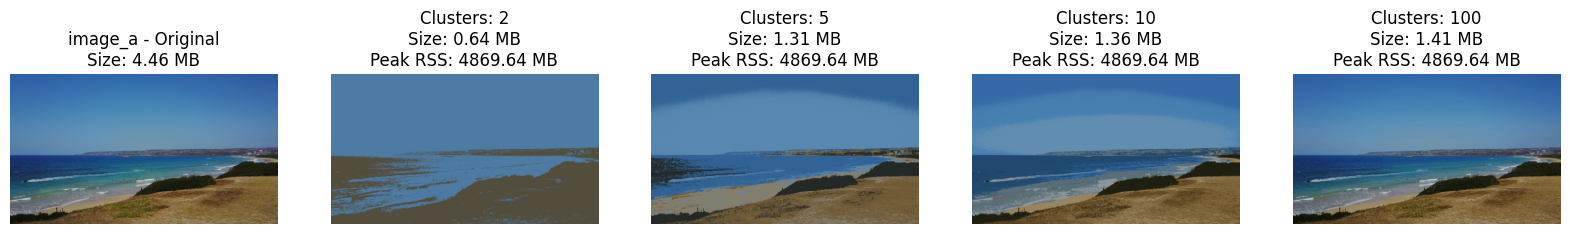

Processing image_b...
  image_b (Clusters: 2): Time: 5.43s, Max RSS increase: 0.00 MB (Total Max RSS: 4869.64 MB), Compressed Size: 0.97 MB (Ratio: 4.28x, Reduction: 76.63%) 
  image_b (Clusters: 5): Time: 10.44s, Max RSS increase: 0.00 MB (Total Max RSS: 4869.64 MB), Compressed Size: 1.56 MB (Ratio: 2.66x, Reduction: 62.45%) 
  image_b (Clusters: 10): Time: 22.19s, Max RSS increase: 0.00 MB (Total Max RSS: 4869.64 MB), Compressed Size: 1.86 MB (Ratio: 2.24x, Reduction: 55.39%) 
  image_b (Clusters: 100): Time: 233.16s, Max RSS increase: 0.00 MB (Total Max RSS: 4869.64 MB), Compressed Size: 1.86 MB (Ratio: 2.24x, Reduction: 55.40%) 


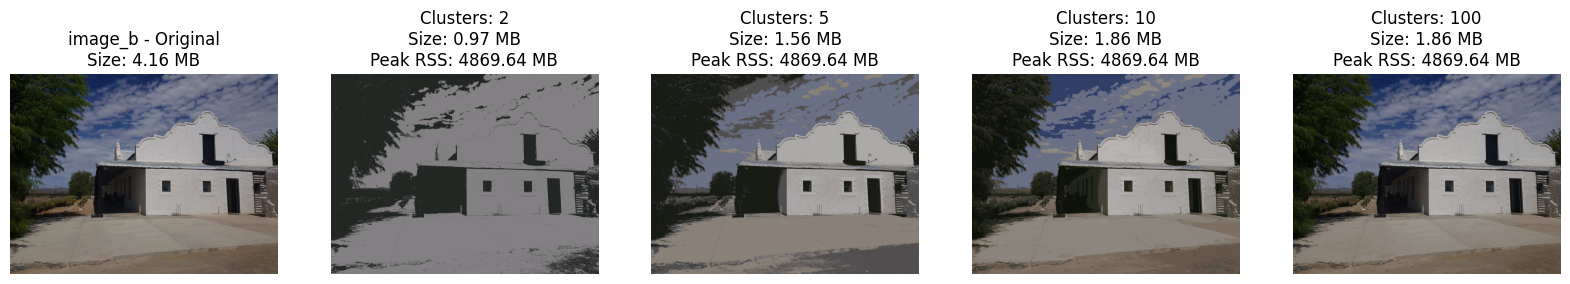

Processing image_c...
  image_c (Clusters: 2): Time: 7.12s, Max RSS increase: 0.00 MB (Total Max RSS: 4869.64 MB), Compressed Size: 1.08 MB (Ratio: 3.78x, Reduction: 73.54%) 
  image_c (Clusters: 5): Time: 8.93s, Max RSS increase: 0.00 MB (Total Max RSS: 4869.64 MB), Compressed Size: 1.74 MB (Ratio: 2.34x, Reduction: 57.31%) 
  image_c (Clusters: 10): Time: 17.40s, Max RSS increase: 0.00 MB (Total Max RSS: 4869.64 MB), Compressed Size: 1.91 MB (Ratio: 2.13x, Reduction: 52.99%) 
  image_c (Clusters: 100): Time: 323.19s, Max RSS increase: 0.00 MB (Total Max RSS: 4869.64 MB), Compressed Size: 1.92 MB (Ratio: 2.12x, Reduction: 52.72%) 


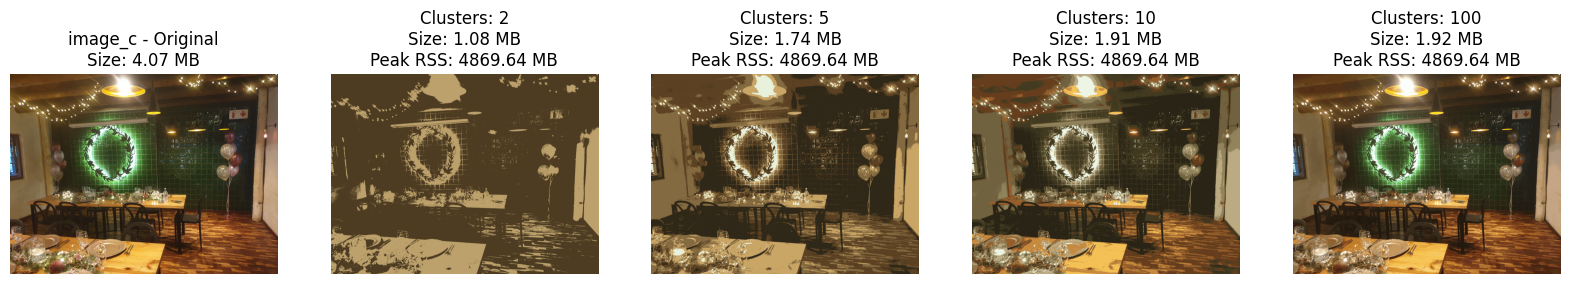

In [23]:
def compress_image_kmeans(image, n_clusters):
    # Image to NumPy array
    image_np = np.array(image)

    # Reshape the image
    h, w, c = image_np.shape
    pixels = image_np.reshape(-1, c)

    # K-means
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
    kmeans.fit(pixels)
    compressed_pixels = kmeans.cluster_centers_[kmeans.labels_]

    # Reshape back
    compressed_image_np = compressed_pixels.reshape(h, w, c)

    # back to a  Image
    compressed_image = Image.fromarray(compressed_image_np.astype('uint8'))

    return compressed_image

images_to_process = {
    'image_a': image_a,
    'image_b': image_b,
    'image_c': image_c
}

original_file_paths = {
    'image_a': '/content/sample_data/a.JPG',
    'image_b': '/content/sample_data/b.jpg',
    'image_c': '/content/sample_data/c.jpg'
}

n_clusters_list = [2, 5, 10, 100]

for img_name, original_image in images_to_process.items():
    print(f"Processing {img_name}...")

    # original image file size
    original_size_bytes = os.path.getsize(original_file_paths[img_name])
    original_size_mb = original_size_bytes / (1024 * 1024)

    plt.figure(figsize=(20, 5))

    # Display original image
    plt.subplot(1, len(n_clusters_list) + 1, 1)
    plt.imshow(original_image)
    plt.title(f'{img_name} - Original\nSize: {original_size_mb:.2f} MB') # Add size to title
    plt.axis('off')

    # Display compressed images
    for i, n_clusters in enumerate(n_clusters_list):

        mem_before_kb = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss

        start_time = time.time()
        compressed_img = compress_image_kmeans(original_image, n_clusters)
        end_time = time.time()
        time_taken = end_time - start_time

        mem_after_kb = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
        memory_used_mb = (mem_after_kb - mem_before_kb) / 1024.0

        temp_compressed_path = f'/tmp/compressed_{img_name}_{n_clusters}.jpg'
        compressed_img.save(temp_compressed_path, format='JPEG', quality=85)
        compressed_size_bytes = os.path.getsize(temp_compressed_path)
        compressed_size_mb = compressed_size_bytes / (1024 * 1024)
        compression_ratio = original_size_bytes / compressed_size_bytes if compressed_size_bytes > 0 else float('inf')
        size_reduction_percent = ((original_size_bytes - compressed_size_bytes) / original_size_bytes) * 100

        os.remove(temp_compressed_path)

        print(f"  {img_name} (Clusters: {n_clusters}): Time: {time_taken:.2f}s, Max RSS increase: {memory_used_mb:.2f} MB (Total Max RSS: {mem_after_kb / 1024.0:.2f} MB), Compressed Size: {compressed_size_mb:.2f} MB (Ratio: {compression_ratio:.2f}x, Reduction: {size_reduction_percent:.2f}%) ")

        plt.subplot(1, len(n_clusters_list) + 1, i + 2)
        plt.imshow(compressed_img)
        plt.title(f'Clusters: {n_clusters}\nSize: {compressed_size_mb:.2f} MB\nPeak RSS: {mem_after_kb / 1024.0:.2f} MB')
        plt.axis('off')
    plt.show()

In [24]:
output = """
Processing image_a...
  image_a (Clusters: 2): Time: 3.69s, Max RSS increase: 0.00 MB (Total Max RSS: 4443.38 MB), Compressed Size: 0.64 MB (Ratio: 6.98x, Reduction: 85.67%)
  image_a (Clusters: 5): Time: 10.89s, Max RSS increase: 0.00 MB (Total Max RSS: 4443.38 MB), Compressed Size: 1.31 MB (Ratio: 3.42x, Reduction: 70.72%)
  image_a (Clusters: 10): Time: 13.57s, Max RSS increase: 0.00 MB (Total Max RSS: 4443.38 MB), Compressed Size: 1.36 MB (Ratio: 3.28x, Reduction: 69.50%)
  image_a (Clusters: 100): Time: 219.10s, Max RSS increase: 0.00 MB (Total Max RSS: 4443.38 MB), Compressed Size: 1.41 MB (Ratio: 3.17x, Reduction: 68.43%)

Processing image_b...
  image_b (Clusters: 2): Time: 6.39s, Max RSS increase: 0.00 MB (Total Max RSS: 4443.38 MB), Compressed Size: 0.97 MB (Ratio: 4.28x, Reduction: 76.63%)
  image_b (Clusters: 5): Time: 11.08s, Max RSS increase: 0.00 MB (Total Max RSS: 4443.38 MB), Compressed Size: 1.56 MB (Ratio: 2.66x, Reduction: 62.45%)
  image_b (Clusters: 10): Time: 15.92s, Max RSS increase: 0.00 MB (Total Max RSS: 4443.38 MB), Compressed Size: 1.86 MB (Ratio: 2.24x, Reduction: 55.39%)
  image_b (Clusters: 100): Time: 235.79s, Max RSS increase: 426.26 MB (Total Max RSS: 4869.64 MB), Compressed Size: 1.86 MB (Ratio: 2.24x, Reduction: 55.40%)

Processing image_c...
  image_c (Clusters: 2): Time: 6.65s, Max RSS increase: 0.00 MB (Total Max RSS: 4869.64 MB), Compressed Size: 1.08 MB (Ratio: 3.78x, Reduction: 73.54%)
  image_c (Clusters: 5): Time: 7.74s, Max RSS increase: 0.00 MB (Total Max RSS: 4869.64 MB), Compressed Size: 1.74 MB (Ratio: 2.34x, Reduction: 57.31%)
  image_c (Clusters: 10): Time: 16.78s, Max RSS increase: 0.00 MB (Total Max RSS: 4869.64 MB), Compressed Size: 1.91 MB (Ratio: 2.13x, Reduction: 52.99%)
  image_c (Clusters: 100): Time: 325.88s, Max RSS increase: 0.00 MB (Total Max RSS: 4869.64 MB), Compressed Size: 1.92 MB (Ratio: 2.12x, Reduction: 52.72%)
"""

data = []

original_file_paths = {
    'image_a': '/content/sample_data/a.JPG',
    'image_b': '/content/sample_data/b.jpg',
    'image_c': '/content/sample_data/c.jpg'
}
original_sizes_mb = {}
for img_name_key, path in original_file_paths.items():
    original_sizes_mb[img_name_key] = os.path.getsize(path) / (1024 * 1024)

# compression results
metrics_pattern = re.compile(r"\s+(image_[a-c]+) \(Clusters: (\d+)\): Time: (\d+\.\d+)s, Max RSS increase: (\d+\.\d+) MB \(Total Max RSS: (\d+\.\d+) MB\), Compressed Size: (\d+\.\d+) MB \(Ratio: (\d+\.\d+)x, Reduction: (\d+\.\d+)%\)")

output_lines = output.split('\n')

for line in output_lines:
    metrics_match = metrics_pattern.match(line)
    if metrics_match:
        img_name = metrics_match.group(1)
        n_clusters = int(metrics_match.group(2))
        time_taken = float(metrics_match.group(3))
        max_rss_increase = float(metrics_match.group(4))
        total_max_rss = float(metrics_match.group(5))
        compressed_size = float(metrics_match.group(6))
        ratio = float(metrics_match.group(7))
        reduction = float(metrics_match.group(8))

        current_original_size = original_sizes_mb.get(img_name, 0.0)

        data.append({
            'Image ID': img_name,
            'Nr Clusters': n_clusters,
            'Time taken (s)': time_taken,
            'Max RSS Increase (MB)': max_rss_increase,
            'Total Max RSS (MB)': total_max_rss,
            'Original Size (MB)': current_original_size,
            'Compressed Size (MB)': compressed_size,
            'Ratio': ratio,
            'Reduction (%)': reduction
        })

summary_df = pd.DataFrame(data)
display(summary_df)


,Image ID,Nr Clusters,Time taken (s),Max RSS Increase (MB),Total Max RSS (MB),Original Size (MB),Compressed Size (MB),Ratio,Reduction (%)
0,image_a,2,3.69,0.00,4443.38,4.462438,0.64,6.98,85.67
1,image_a,5,10.89,0.00,4443.38,4.462438,1.31,3.42,70.72
2,image_a,10,13.57,0.00,4443.38,4.462438,1.36,3.28,69.50
3,image_a,100,219.10,0.00,4443.38,4.462438,1.41,3.17,68.43
4,image_b,2,6.39,0.00,4443.38,4.159688,0.97,4.28,76.63
5,image_b,5,11.08,0.00,4443.38,4.159688,1.56,2.66,62.45
6,image_b,10,15.92,0.00,4443.38,4.159688,1.86,2.24,55.39
7,image_b,100,235.79,426.26,4869.64,4.159688,1.86,2.24,55.40
8,image_c,2,6.65,0.00,4869.64,4.069292,1.08,3.78,73.54
9,image_c,5,7.74,0.00,4869.64,4.069292,1.74,2.34,57.31
